In [207]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [208]:
# Nbr of particles
N = 10
r = 10
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
sat = [1:20:101;]
Ω_RO = γ.*sqrt.(sat/2)
n0 = 1e0

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:00<Inf:Inf, InfGs/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [00:00<00:00, 33it/s]
100.0%┣██████████████████████████████████████████████┫ 6/6 [00:00<00:00, 37it/s]
100.0%┣██████████████████████████████████████████████┫ 6/6 [00:00<00:00, 36it/s]


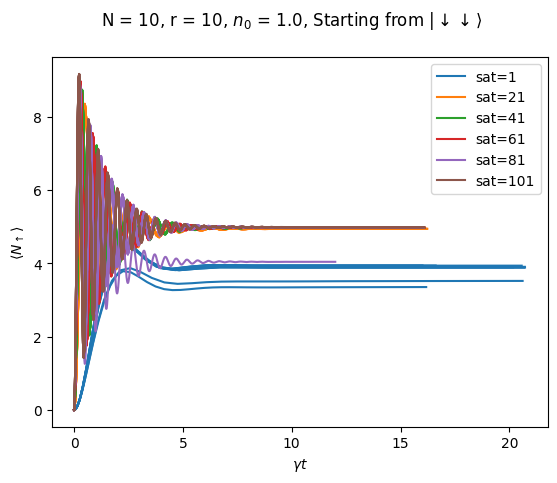

In [209]:
close("all")
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
100.0%┣█████████████████████████████████████████████┫ 6/6 [00:00<00:00, 241it/s]
100.0%┣█████████████████████████████████████████████┫ 6/6 [00:00<00:00, 231it/s]


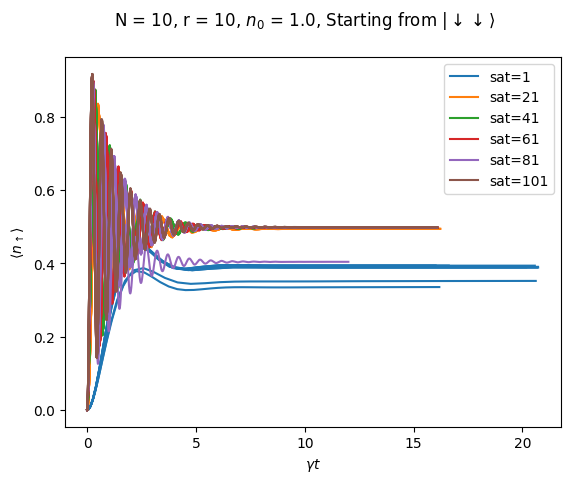

In [210]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:10#length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

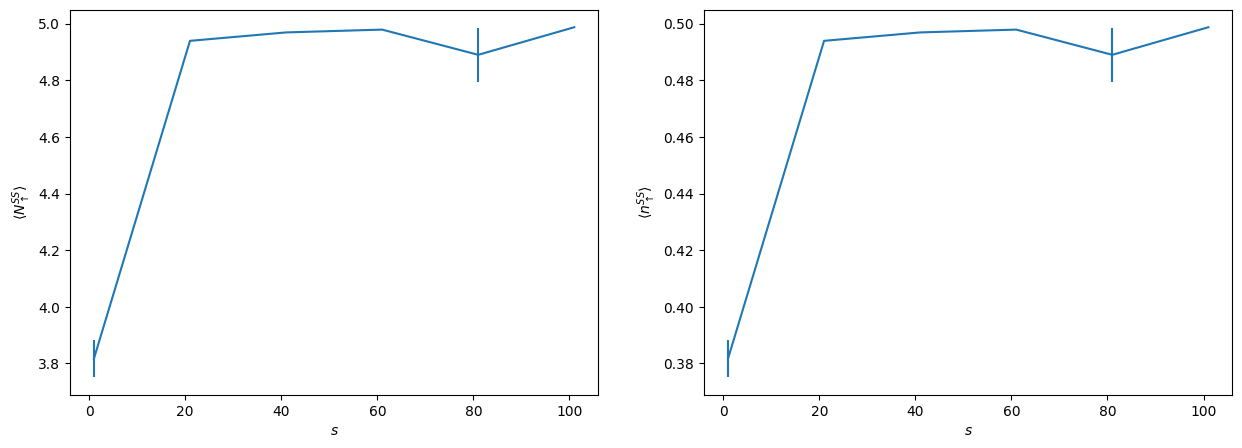

In [211]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")


pygui(false); gcf();
# pygui(true); show()

# Comparison with spontaneous emission

In [212]:
function deriv_indep_atoms(du, u, p, t)
    γ, Ω = p[1], p[2]
    du[1] = -2γ*u[1] + 1im*Ω*(u[2]-conj(u[2])) # u[1] = ρee, u[2] = ρeg
    du[2] = -γ*u[2] + 1im*Ω*(2*u[1]-1)
end

deriv_indep_atoms (generic function with 1 method)

# Fit the independant case to the SS interacting case

In [213]:
function fit_γ_SE(n_up_SS, Ω)
    return Ω*sqrt(1/n_up_SS - 2)
end

fit_γ_SE (generic function with 1 method)

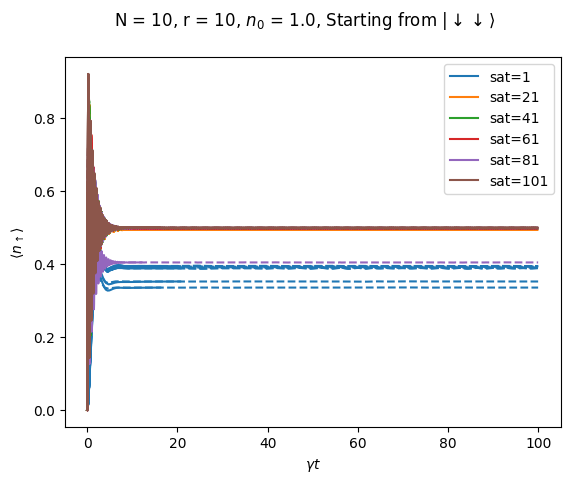

In [214]:
close("all")
fig, ax = subplots()

u0_indep = zeros(ComplexF64, 2)
decay_rate_interactions_eq_indep = zeros((length(sat), r))


for (i, s) in enumerate(sat)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, color=line.get_color()) # marker="o", markersize=1,
            end

            if popup_t_N[i][j][end] > 0
                γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N, Ω_RO[i])
                prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO[i]])
                sol_indep = solve(prob)
                plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color=line.get_color())

                decay_rate_interactions_eq_indep[i, j] = γ_fit_SE
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

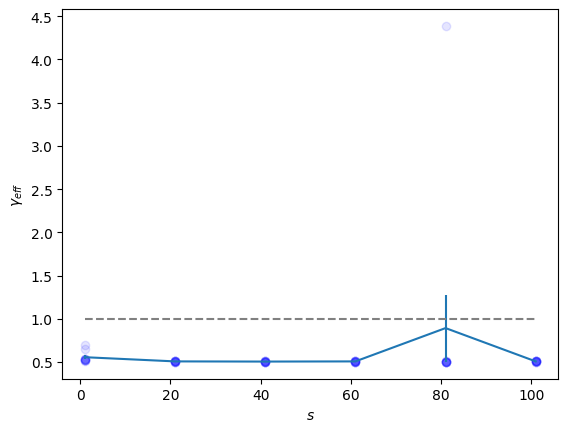

In [215]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(s, decay_rate_interactions_eq_indep[i, j], color="blue", alpha=0.1)
        end
    end
end
 
xlabel(L"s")
ylabel(L"\gamma_{eff}")

hlines(1, sat[1], sat[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false); 

### Weighted equivalent independant decay rate

In [216]:
sol_t_N[1][1]

245-element Vector{ComplexF64}:
    0.4191374125692366 - 2.4697905721197644e-19im
   0.37359872085032036 - 5.01241306491437e-19im
    0.4010343206144686 - 2.9138839922261826e-19im
   0.40017187130180226 - 6.801186013865395e-19im
    0.3934749606694339 + 1.5215897554700163e-18im
   0.37823616241372987 - 4.771724426045989e-19im
   0.40425569678757056 + 2.9845678139815125e-19im
    0.3751688501696042 + 2.3658264386368597e-18im
   0.40321408389748176 - 1.8235301582665376e-18im
    0.3911712249089552 + 3.0791782519319556e-19im
   0.20624814040413914 + 0.1508567403672089im
  -0.22351454773889323 - 0.1745448316264812im
  -0.27647994955468064 + 0.019240141745541207im
                       ⋮
 -0.016618717339649914 - 0.0739425672672184im
  0.011943354680974216 - 0.08278221408801106im
  -0.06810153741655131 - 0.04624369866526907im
   0.02693225067957856 + 0.08414740812952447im
 -0.055774225810278445 + 0.05046346420499063im
   -0.0807198703822823 + 0.046014667803561775im
   0.06971093519656754 - 

In [217]:
decay_rate_interactions_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            decay_rate_interactions_eq_indep_weighted[i, j] += 2*decay_rate_interactions_eq_indep[i, j]*sum(sol_SS[a] for a = 1:N)
            decay_rate_interactions_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_interactions_eq_indep_weighted

6×10 Matrix{ComplexF64}:
 3.86021+4.91209e-19im  4.56671+1.03946e-18im  …  4.67446-3.20904e-18im
 6.09139+1.28836e-19im  6.88568+1.59779e-19im     4.02318+1.94751e-19im
 4.97559-4.72339e-19im  5.53798+6.70202e-20im     3.83453+4.83077e-20im
 5.51365+2.82829e-19im  3.92508-1.27093e-19im     5.62165+2.96793e-19im
 33.9928+4.99562e-17im  4.18208+1.24297e-20im     3.48661+3.56606e-19im
 6.24751-6.9987e-19im   6.39215-1.03049e-18im  …  4.11913-1.92991e-19im

In [218]:
decay_rate_interactions_eq_indep_weighted = real.(decay_rate_interactions_eq_indep_weighted)

6×10 Matrix{Float64}:
  3.86021  4.56671  4.46067  3.69793  …  5.03957  4.89307  4.11283  4.67446
  6.09139  6.88568  4.77629  4.28338     4.33554  4.45176  5.17178  4.02318
  4.97559  5.53798  3.86713  5.30437     4.83326  4.6981   4.1815   3.83453
  5.51365  3.92508  4.55749  5.73153     5.10966  4.24891  3.2964   5.62165
 33.9928   4.18208  7.13281  2.49733     5.86186  4.63306  6.56314  3.48661
  6.24751  6.39215  3.6693   3.97089  …  4.93784  3.37193  3.42199  4.11913

### Weighted corresponding independant decay rate

In [219]:
decay_rate_independant_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            decay_rate_independant_eq_indep_weighted[i, j] += 2*γ*sum(sol_SS[a] for a = 1:N)
            decay_rate_independant_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_independant_eq_indep_weighted

6×10 Matrix{ComplexF64}:
 7.65113+9.46722e-19im  8.29681+1.98216e-18im  …  6.67637-4.57559e-18im
 10.9663+2.54337e-19im  11.7121+3.12468e-19im     8.86548+3.82031e-19im
 9.86599-9.30014e-19im  10.4556+1.32667e-19im     8.70834+9.48079e-20im
 10.3878+5.54021e-19im  8.81028-2.49494e-19im     10.5408+5.86529e-19im
 6.62589+1.13876e-17im  9.11939+2.46272e-20im     8.41528+7.05342e-19im
 11.1474-1.37564e-18im  11.2742-2.01846e-18im  …  9.07531-3.83572e-19im

In [220]:
decay_rate_independant_eq_indep_weighted = real.(decay_rate_independant_eq_indep_weighted)

6×10 Matrix{Float64}:
  7.65113   8.29681   8.26298   7.30181  …  8.51377   7.78238   6.67637
 10.9663   11.7121    9.61552   9.15846     9.33217  10.0712    8.86548
  9.86599  10.4556    8.78248  10.195       9.61754   9.08611   8.70834
 10.3878    8.81028   9.44275  10.6233      9.08163   8.21734  10.5408
  6.62589   9.11939  12.0435    7.42188     9.5947   11.4793    8.41528
 11.1474   11.2742    8.5747    8.85743  …  8.24697   8.34271   9.07531

### Plots

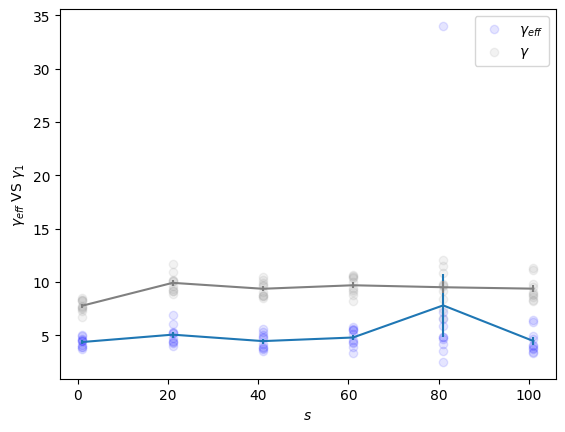

In [221]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"γ"])
xlabel(L"s")
ylabel(L"$\gamma_{eff}$ VS $\gamma_1$")

# hlines(1, N_list[1], N_list[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false);

# Compute a decay rate from the $\Gamma$ matrix

In [222]:
decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if a == b
                        decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        # corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
        end
    end
end
decay_rate_interactions_Gamma_matrix

6×10 Matrix{ComplexF64}:
 3.87096+2.06794e-18im  3.46848-1.80403e-18im  …  3.08608+4.71998e-18im
 4.85656-1.28763e-19im  4.22076-1.30903e-19im     4.50248+6.65367e-19im
 4.88493-3.53438e-19im  4.24245-6.51353e-21im     4.52698-2.29901e-20im
 4.89467+3.45296e-19im  4.24949-5.51097e-20im      4.5351+3.79006e-19im
 3.89437-3.82242e-17im  4.25331+9.28028e-21im     4.54102+3.20849e-19im
 4.90589-1.14905e-18im  4.25556-1.39225e-18im  …  4.54234-1.17797e-19im

In [223]:
decay_rate_interactions_Gamma_matrix = real.(decay_rate_interactions_Gamma_matrix)

6×10 Matrix{Float64}:
 3.87096  3.46848  3.83163  3.59379  …  3.34414  4.36799  3.54066  3.08608
 4.85656  4.22076  4.7293   4.45437     4.62604  5.70821  4.37634  4.50248
 4.88493  4.24245  4.75735  4.47792     4.65208  5.74663  4.39816  4.52698
 4.89467  4.24949  4.76624  4.48617     4.6609   5.75903  4.40592  4.5351
 3.89437  4.25331  4.77117  4.49062     4.66563  5.7668   4.40983  4.54102
 4.90589  4.25556  4.77399  4.4931   …  4.66805  5.7703   4.41248  4.54234

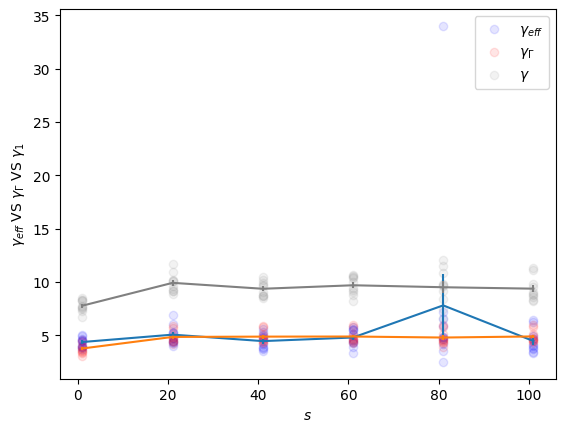

In [224]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], color="red", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end


legend([L"\gamma_{eff}", L"\gamma_\Gamma", L"γ"])

xlabel(L"s")
ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
# pygui(true); show()
pygui(false);

# Plot the decay of SR without SE

In [225]:
function decay_atoms_indep(sat, N, γ)
    return N*γ/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep (generic function with 1 method)

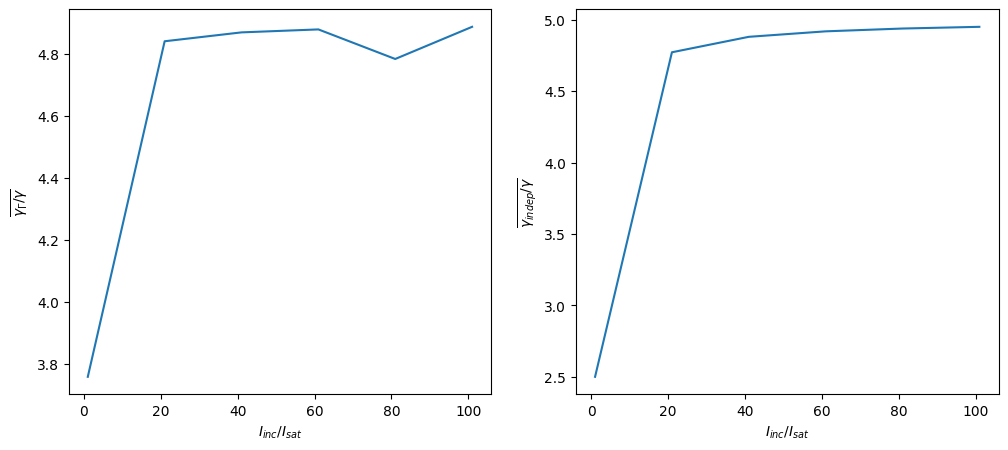

In [226]:
close("all")
fig, axs = subplots(1, 2, figsize=(12, 5))

axs[1].plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
axs[1].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[1].set_ylabel(L"\overline{\gamma_\Gamma/\gamma}")

axs[2].plot(sat, decay_atoms_indep(sat, N, γ))
axs[2].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[2].set_ylabel(L"\overline{\gamma_{indep}/\gamma}")

# pygui(true); show();
pygui(false);

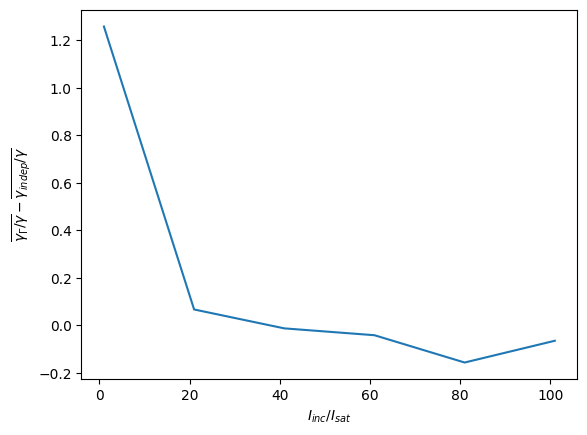

In [227]:
close("all")
fig, axs = subplots()

plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]-decay_atoms_indep(sat, N, γ))
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\overline{\gamma_\Gamma/\gamma}-\overline{\gamma_{indep}/\gamma}")
 
# pygui(true); show();
pygui(false);

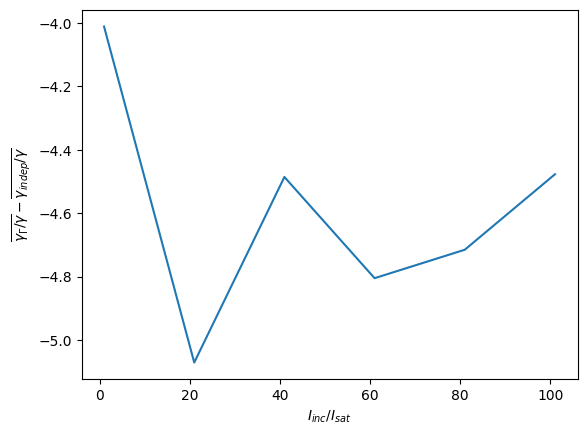

In [228]:

close("all")
fig, axs = subplots()

plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]-[mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\overline{\gamma_\Gamma/\gamma}-\overline{\gamma_{indep}/\gamma}")
 
# pygui(true); show();
pygui(false);